<a href="https://colab.research.google.com/github/puccash/Data_Test/blob/Data-Test/Master_251017_ipynb_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1-1. 구글 마운트
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# # 한글 깨짐 방지
# !sudo apt-get install -y fonts-nanum
# !sudo fc-cache -fv
# !rm ~/.cache/matplotlib -rf

In [ ]:
# 1-2. 라이브러리 불러오기
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import folium # 지도 시각화를 위한 라이브러리
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False # 마이너스 부호 깨짐 방지

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/01. 공모전/03. 빅콘테스트/data/master_data.csv', encoding='cp949')

In [ ]:
for col in data.select_dtypes(include=['float']).columns:
    data[col] = data[col].fillna(0).astype(int)
data.head()

,가맹점ID,기준년월,운영개월수구간,매출금액구간,매출건수구간,고객수구간,객단가구간,취소율구간,배달매출비율,업종내매출순위비율,상권내매출순위비율,업종내폐업비율,상권내폐업비율,남성20대이하비율,남성30대비율,남성40대비율,남성50대비율,남성60대이상비율,여성20대이하비율,여성30대비율,여성40대비율,여성50대비율,여성60대이상비율,재방문율,신규고객비율,거주고객비율,직장고객비율,유동고객비율,MCT_BSE_AR,가맹점명,브랜드코드,지역,업종,상권,개설일,폐업일,폐업여부,프랜차이즈여부,업종_대분류,상권_여부
0,000F03E44A,2024-04-01,4,5,5,5,5,1,1,4,4,2,2,4,2,2,4,4,2,1,1,1,3,1,4,1,3,4,서울특별시 성동구 왕십리로4가길 9,육육**,개인,서울 성동구,중식-딤섬/중식만두,뚝섬,2022-02-25,영업중,0,0,중식,1
1,000F03E44A,2023-12-01,4,6,6,6,6,1,1,4,4,2,2,3,4,1,4,1,2,3,1,3,1,1,1,1,3,5,서울특별시 성동구 왕십리로4가길 9,육육**,개인,서울 성동구,중식-딤섬/중식만두,뚝섬,2022-02-25,영업중,0,0,중식,1
2,002816BA73,2024-04-01,2,3,4,4,2,6,0,2,2,2,2,2,4,4,4,3,1,1,1,2,2,1,2,2,4,3,서울 성동구 청계천로10나길 78,자갈***********,개인,서울 성동구,요리주점,마장동,2014-05-07,영업중,0,0,주점,1
3,002816BA73,2024-11-01,2,3,4,4,2,6,0,2,2,2,2,2,4,4,4,4,1,1,2,2,2,1,2,1,3,4,서울 성동구 청계천로10나길 78,자갈***********,개인,서울 성동구,요리주점,마장동,2014-05-07,영업중,0,0,주점,1
4,002816BA73,2024-06-01,2,4,4,4,2,1,0,2,2,2,2,2,4,4,4,3,1,1,1,2,2,1,1,1,3,4,서울 성동구 청계천로10나길 78,자갈***********,개인,서울 성동구,요리주점,마장동,2014-05-07,영업중,0,0,주점,1


In [ ]:
# 상권 위험도 분석
# 상권별 평균적인 특성을 보기 위해 그룹화 및 집계
district_df = data.groupby('상권').agg(
    store_count=('가맹점ID', 'nunique'), # 상권 내 가맹점 수
    avg_closure_rate=('상권내폐업비율', 'mean'), # 상권 내 평균 폐업률 (높을수록 위험)
    avg_sales_rank=('상권내매출순위비율', 'mean'), # 상권 내 평균 매출 순위 비율 (낮을수록 상위권)
    avg_industry_closure_rate=('업종내폐업비율', 'mean') # 상권 내 업종 평균 폐업률 (높을수록 위험)
).reset_index()

print("\n--- 상권별 집계 데이터프레임 (district_df) ---")
display(district_df)


--- 상권별 집계 데이터프레임 (district_df) ---


,상권,store_count,avg_closure_rate,avg_sales_rank,avg_industry_closure_rate
0,건대입구,1,4.000000,2.916667,2.000000
1,금남시장,249,2.913404,2.720068,1.737575
2,답십리,179,2.608671,2.488327,1.707893
3,동대문역사문화공원역,1,2.333333,4.000000,1.083333
4,뚝섬,468,2.641714,2.311013,1.796084
5,마장동,257,1.917837,2.732971,1.272472
6,미아사거리,1,4.000000,4.000000,2.000000
7,방배역,1,3.625000,4.000000,1.041667
8,상권없음,1047,1.000000,0.000000,1.691816
9,서면역,1,4.000000,1.000000,0.958333


In [ ]:
# 1-1. 상권내 폐업비율 구간별로 상권 분류 (안정 vs 위험)
# 사분위수를 기준으로 '안정', '주의', '위험', '고위험' 4등급으로 분류
# 폐업률은 높을수록 위험도가 높습니다.
district_df['위험도등급'] = pd.qcut(
    district_df['avg_closure_rate'],
    q=4,
    labels=['안정', '주의', '위험', '고위험']
)

print("--- 폐업률 기반 상권 위험도 분류 결과 (위험도 높은 순) ---")
display(district_df[['상권', 'avg_closure_rate', '위험도등급']].sort_values('avg_closure_rate', ascending=False))

--- 폐업률 기반 상권 위험도 분류 결과 (위험도 높은 순) ---


,상권,avg_closure_rate,위험도등급
0,건대입구,4.000000,고위험
18,풍산지구,4.000000,고위험
21,화양시장,4.000000,고위험
13,오남,4.000000,고위험
9,서면역,4.000000,고위험
6,미아사거리,4.000000,고위험
15,왕십리,3.871218,위험
20,행당,3.737357,위험
19,한양대,3.645500,위험
7,방배역,3.625000,위험



--- 상권 위험도별 평균 업종 폐업률 ---
위험도등급
안정     1.659042
주의     1.818721
위험     1.758408
고위험    1.869919
Name: 업종내폐업비율, dtype: float64


/tmp/ipython-input-1511086801.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  correlation_analysis = df_with_risk.groupby('위험도등급')['업종내폐업비율'].mean()
/tmp/ipython-input-1511086801.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlation_analysis.index, y=correlation_analysis.values, palette='viridis', order=['안정', '주의', '위험', '고위험'])


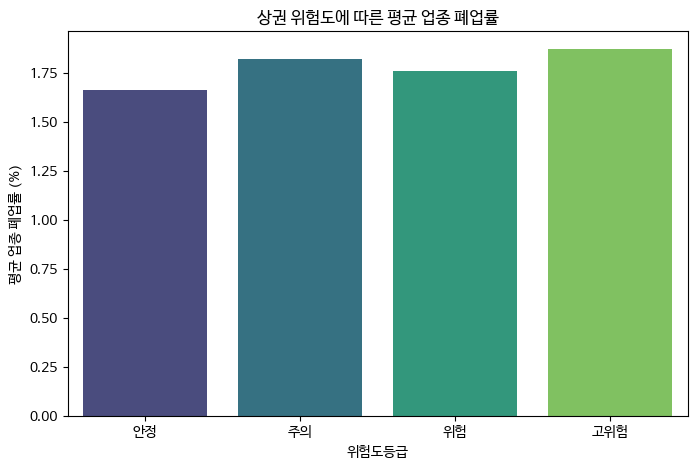

In [ ]:
# 1-2. 업종별 폐업률과 상권 폐업률의 상관관계 분석
# 각 상권의 위험도 등급을 원본 데이터프레임에 병합
df_with_risk = pd.merge(data, district_df[['상권', '위험도등급']], on='상권', how='left')

# 상권 위험도 등급별로 업종 폐업률의 평균을 계산
correlation_analysis = df_with_risk.groupby('위험도등급')['업종내폐업비율'].mean()

print("\n--- 상권 위험도별 평균 업종 폐업률 ---")
print(correlation_analysis)

plt.figure(figsize=(8, 5))
sns.barplot(x=correlation_analysis.index, y=correlation_analysis.values, palette='viridis', order=['안정', '주의', '위험', '고위험'])
plt.title('상권 위험도에 따른 평균 업종 폐업률')
plt.ylabel('평균 업종 폐업률 (%)')
plt.show()

--- 매출 순위 비율 vs 폐업률 상관계수 ---
avg_sales_rank는 1에 가까울수록 상위권(좋음)을 의미합니다.
따라서 폐업률(avg_closure_rate)과 양의 상관관계가 나타나면, '순위가 낮아질수록(숫자가 커질수록) 폐업률이 높아진다'는 의미입니다.


,avg_sales_rank,avg_closure_rate
avg_sales_rank,1.000000,0.075529
avg_closure_rate,0.075529,1.000000


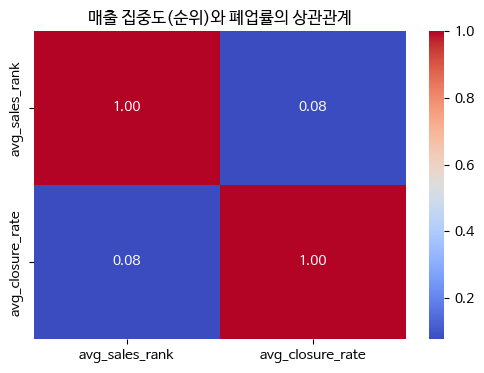


--- 매출 상위 Top 10 상권의 안정성(위험도) ---


,상권,avg_sales_rank,avg_closure_rate,위험도등급
9,서면역,1.000000,4.000000,고위험
10,성수,2.223404,2.660456,주의
4,뚝섬,2.311013,2.641714,안정
14,옥수,2.412432,2.688038,주의
2,답십리,2.488327,2.608671,안정
17,장한평자동차,2.490123,2.000000,안정
20,행당,2.591626,3.737357,위험
15,왕십리,2.658268,3.871218,위험
11,신금호,2.679635,3.547550,위험
19,한양대,2.690795,3.645500,위험



--- 업종별 평균 매출 집중도와 폐업률 ---


,avg_sales_rank,avg_closure_rate
업종_대분류,,
중식,1.947115,2.983774
한식-육류/고기,1.970544,3.049459
일식,2.095649,3.037108
한식-해물/생선,2.129612,3.038316
세계요리,2.155887,3.049751


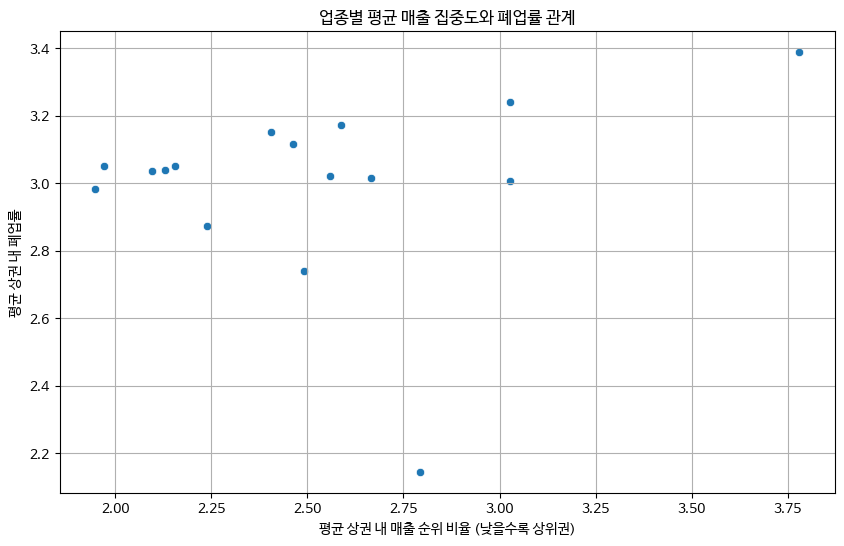

In [ ]:
# 2-1. 상권내매출순위비율 vs 상권내폐업비율 간 상관계수
# '상권없음' 데이터는 순위가 0으로 왜곡되어 있으므로 제외하고 분석
corr_df = district_df[district_df['상권']!= '상권없음']
correlation = corr_df[['avg_sales_rank', 'avg_closure_rate']].corr()

print("--- 매출 순위 비율 vs 폐업률 상관계수 ---")
print("avg_sales_rank는 1에 가까울수록 상위권(좋음)을 의미합니다.")
print("따라서 폐업률(avg_closure_rate)과 양의 상관관계가 나타나면, '순위가 낮아질수록(숫자가 커질수록) 폐업률이 높아진다'는 의미입니다.")
display(correlation)

plt.figure(figsize=(6, 4))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('매출 집중도(순위)와 폐업률의 상관관계')
plt.show()

# 2-2. 매출 상위 상권이 실제로 안정적인지 검증
# 매출 순위 비율이 낮은(상위권) 상권 Top 10 추출
top_sales_districts = corr_df.sort_values('avg_sales_rank').head(10)

print("\n--- 매출 상위 Top 10 상권의 안정성(위험도) ---")
display(top_sales_districts[['상권', 'avg_sales_rank', 'avg_closure_rate', '위험도등급']])

# 2-3. 업종별로 매출 집중도와 폐업률 비교
# 업종별로 상권 내 평균 매출 순위와 폐업률 계산
industry_vs_sales_closure = data[data['상권']!= '상권없음'].groupby('업종_대분류').agg(
    avg_sales_rank=('상권내매출순위비율', 'mean'),
    avg_closure_rate=('상권내폐업비율', 'mean')
).dropna()

print("\n--- 업종별 평균 매출 집중도와 폐업률 ---")
display(industry_vs_sales_closure.sort_values('avg_sales_rank').head())

plt.figure(figsize=(10, 6))
sns.scatterplot(data=industry_vs_sales_closure, x='avg_sales_rank', y='avg_closure_rate')
plt.title('업종별 평균 매출 집중도와 폐업률 관계')
plt.xlabel('평균 상권 내 매출 순위 비율 (낮을수록 상위권)')
plt.ylabel('평균 상권 내 폐업률')
plt.grid(True)
plt.show()

--- 업종별 상권 위험도 분포 (비율 %) ---
예: '한식' 업종의 가맹점 중 몇 %가 '안정' 등급의 상권에 위치하는지를 보여줍니다.


/tmp/ipython-input-226205524.py:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  suitability_pivot = df_with_risk.pivot_table(


위험도등급,안정,주의,위험,고위험
업종_대분류,,,,
건강식품/건강원,21.212121,27.272727,51.515152,0.000000
기타,31.914894,26.595745,41.489362,0.000000
분식/패스트푸드,45.495495,24.774775,29.729730,0.000000
세계요리,52.272727,27.272727,18.181818,2.272727
식료품/식자재,54.736842,24.210526,20.701754,0.350877
양식,50.847458,35.593220,12.429379,1.129944
일식,39.800995,34.328358,25.870647,0.000000
주점,32.432432,30.501931,37.065637,0.000000
중식,44.339623,31.132075,24.528302,0.000000


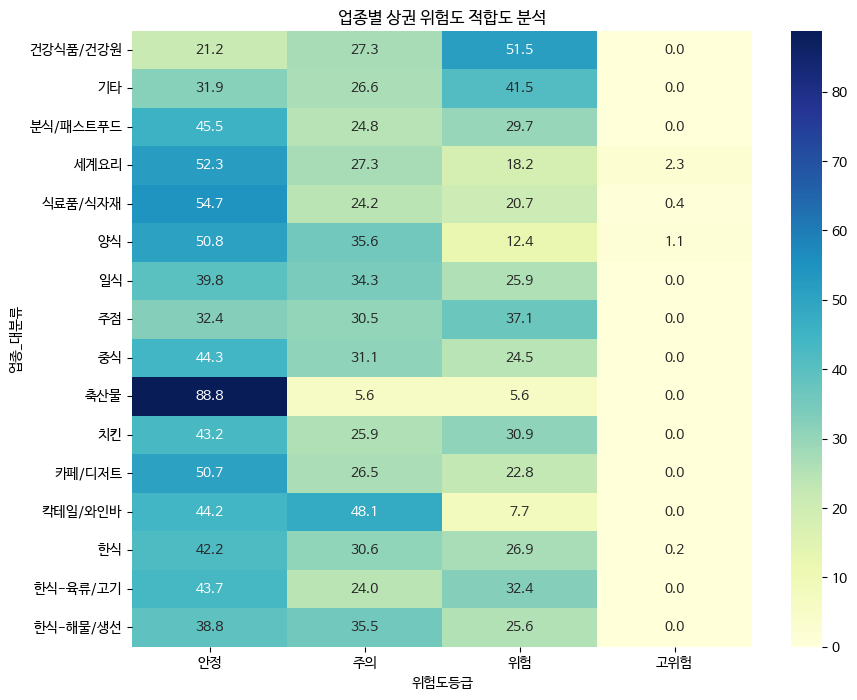


--- 업종별 (매출 비율 vs 폐업률) 상관계수 ---
상관계수가 음수(-)이면 '매출 비율이 높을수록 폐업률이 낮아진다'는 긍정적인 관계를 의미합니다.
업종_대분류
한식-육류/고기   -0.459684
식료품/식자재    -0.412990
치킨         -0.402335
주점         -0.381056
축산물        -0.357863
카페/디저트     -0.126710
분식/패스트푸드   -0.115565
중식         -0.115115
칵테일/와인바    -0.105367
일식          0.014181
한식-해물/생선    0.031964
기타          0.045563
한식          0.093708
세계요리        0.245253
건강식품/건강원    0.297222
양식          0.392684
Name: (avg_sales_ratio, avg_closure_rate), dtype: float64


In [ ]:
# 3-1 & 3-2. 업종별로 "안정 상권"과 "위험 상권" 매핑
# df_with_risk는 1-3 단계에서 이미 생성됨

# 업종별로 각 위험도 등급의 상권에 몇 개의 가맹점이 있는지 카운트
suitability_pivot = df_with_risk.pivot_table(
    index='업종_대분류',
    columns='위험도등급',
    values='가맹점ID',
    aggfunc='nunique',
    fill_value=0
)

# 각 업종별 총 가맹점 수로 나누어 비율로 변환
suitability_pivot_ratio = suitability_pivot.div(suitability_pivot.sum(axis=1), axis=0) * 100

print("--- 업종별 상권 위험도 분포 (비율 %) ---")
print("예: '한식' 업종의 가맹점 중 몇 %가 '안정' 등급의 상권에 위치하는지를 보여줍니다.")
display(suitability_pivot_ratio)

plt.figure(figsize=(10, 8))
sns.heatmap(suitability_pivot_ratio, annot=True, cmap="YlGnBu", fmt='.1f')
plt.title('업종별 상권 위험도 적합도 분석')
plt.show()

# 3-3. 업종별 매출 비율이 높은 상권에서 폐업률이 낮은지 확인
# '매입율'은 '업종내매출비율'로 대체하여 분석
# '업종내매출비율'은 100%가 평균이므로 높을수록 좋은 지표입니다.
industry_performance_df = data.groupby(['상권', '업종_대분류']).agg(
    avg_sales_ratio=('업종내매출순위비율', 'mean'), # 업종 평균 대비 매출 비율 (높을수록 좋음)
    avg_closure_rate=('상권내폐업비율', 'mean') # 상권 내 폐업률 (높을수록 나쁨)
).reset_index().dropna()

# 업종별로 매출 비율과 폐업률의 상관관계 계산
correlation_by_industry = industry_performance_df.groupby('업종_대분류')[['avg_sales_ratio', 'avg_closure_rate']].corr().unstack().iloc[:, 1]

print("\n--- 업종별 (매출 비율 vs 폐업률) 상관계수 ---")
print("상관계수가 음수(-)이면 '매출 비율이 높을수록 폐업률이 낮아진다'는 긍정적인 관계를 의미합니다.")
print(correlation_by_industry.sort_values())

In [ ]:
from sklearn.tree import DecisionTreeClassifier # 의사결정나무 모델
# 4-1. 모델링을 위한 데이터 준비
# '상권없음' 데이터는 제외
model_df = district_df[district_df['상권']!= '상권없음'].copy()

# 업종 구성 변수 추가 (각 상권의 업종 다양성)
industry_diversity = data.groupby('상권')['업종_대분류'].nunique().reset_index()
industry_diversity.rename(columns={'업종_대분류': '업종다양성'}, inplace=True)
model_df = pd.merge(model_df, industry_diversity, on='상권')

# 4-2. 타겟 변수 생성: 폐업률이 하위 50% (중앙값) 미만이면 '안정'(1), 이상이면 '위험'(0)
median_closure_rate = model_df['avg_closure_rate'].median()
model_df['is_stable'] = (model_df['avg_closure_rate'] < median_closure_rate).astype(int)

print("--- 모델링 데이터셋 및 타겟 변수 생성 결과 ---")
display(model_df.head())
print("\n안정(1)/위험(0) 그룹 분포:\n", model_df['is_stable'].value_counts())

# 4-3. 입력 변수(X)와 타겟 변수(y) 설정
# avg_sales_rank는 낮을수록 좋은 지표. 모델이 이 관계를 학습할 것입니다.
features = ['store_count', 'avg_sales_rank', 'avg_industry_closure_rate', '업종다양성']
X = model_df[features]
y = model_df['is_stable']

# 4-4. 데이터 분할 및 모델 학습/평가
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 로지스틱 회귀 모델
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

print("\n--- 상권 안정성 예측 모델 평가 결과 (로지스틱 회귀) ---")
print(classification_report(y_test, y_pred_lr, target_names=['위험(0)', '안정(1)']))

# 의사결정나무 모델
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

print("\n--- 상권 안정성 예측 모델 평가 결과 (의사결정나무) ---")
print(classification_report(y_test, y_pred_dt, target_names=['위험(0)', '안정(1)']))

--- 모델링 데이터셋 및 타겟 변수 생성 결과 ---


,상권,store_count,avg_closure_rate,avg_sales_rank,avg_industry_closure_rate,위험도등급,업종다양성,is_stable
0,건대입구,1,4.000000,2.916667,2.000000,고위험,1,0
1,금남시장,249,2.913404,2.720068,1.737575,주의,16,1
2,답십리,179,2.608671,2.488327,1.707893,안정,15,1
3,동대문역사문화공원역,1,2.333333,4.000000,1.083333,안정,1,1
4,뚝섬,468,2.641714,2.311013,1.796084,안정,16,1



안정(1)/위험(0) 그룹 분포:
 is_stable
0    11
1    10
Name: count, dtype: int64

--- 상권 안정성 예측 모델 평가 결과 (로지스틱 회귀) ---
              precision    recall  f1-score   support

       위험(0)       1.00      0.50      0.67         4
       안정(1)       0.60      1.00      0.75         3

    accuracy                           0.71         7
   macro avg       0.80      0.75      0.71         7
weighted avg       0.83      0.71      0.70         7


--- 상권 안정성 예측 모델 평가 결과 (의사결정나무) ---
              precision    recall  f1-score   support

       위험(0)       1.00      0.50      0.67         4
       안정(1)       0.60      1.00      0.75         3

    accuracy                           0.71         7
   macro avg       0.80      0.75      0.71         7
weighted avg       0.83      0.71      0.70         7



In [ ]:
def generate_district_report(district_name, report_df, full_df):
    """
    특정 상권에 대한 요약 리포트를 생성하는 함수
    """
    try:
        # ✅ 상권 정보 추출 (iloc[0]로 수정)
        district_info = report_df[report_df['상권'] == district_name].iloc[0]

        # 주요 업종 Top3
        top_industries = (
            full_df[full_df['상권'] == district_name]['업종_대분류']
            .value_counts()
            .head(3)
            .index
            .tolist()
        )

        # 리포트 출력
        report = f"""
        ========================================
        상권 [{district_name}] 요약 리포트
        ========================================
        - 상권 위험도: {district_info['위험도등급']}
        - 평균 폐업률: {district_info['avg_closure_rate']:.2f}%
        - 평균 매출 순위 비율: {district_info['avg_sales_rank']:.2f} (1에 가까울수록 상위권)
        - 가맹점 수: {int(district_info['store_count'])}개
        - 주요 업종: {', '.join(top_industries)}

        [종합 의견]
        '{district_name}' 상권은 폐업률 기준 '{district_info['위험도등급']}' 등급으로 평가됩니다.
        주요 업종은 '{', '.join(top_industries)}'이며, 이 업종들의 성과가 상권 전체의 안정성에 큰 영향을 미칩니다.
        상권 내 평균 매출 순위는 {district_info['avg_sales_rank']:.2f} 수준으로, 상권 내 경쟁 강도를 파악하는 데 참고할 수 있습니다.
        """

        print(report)

    except IndexError:
        print(f"'{district_name}'에 해당하는 상권 정보를 찾을 수 없습니다.")


In [ ]:
# --- 리포트 생성 예시 ---
# 리포트 생성을 위해 district_df를 폐업률 기준으로 정렬
sorted_district_df = district_df.sort_values('avg_closure_rate').reset_index(drop=True)

print("--- '성수' 상권 리포트 ---")
generate_district_report('성수', sorted_district_df, data)
print("\n--- '왕십리' 상권 리포트 ---")
generate_district_report('왕십리', sorted_district_df, data)

--- '성수' 상권 리포트 ---

        상권 [성수] 요약 리포트
        - 상권 위험도: 주의
        - 평균 폐업률: 2.66%
        - 평균 매출 순위 비율: 2.22 (1에 가까울수록 상위권)
        - 가맹점 수: 762개
        - 주요 업종: 한식, 카페/디저트, 한식-육류/고기

        [종합 의견]
        '성수' 상권은 폐업률 기준 '주의' 등급으로 평가됩니다.
        주요 업종은 '한식, 카페/디저트, 한식-육류/고기'이며, 이 업종들의 성과가 상권 전체의 안정성에 큰 영향을 미칩니다.
        상권 내 평균 매출 순위는 2.22 수준으로, 상권 내 경쟁 강도를 파악하는 데 참고할 수 있습니다.
        

--- '왕십리' 상권 리포트 ---

        상권 [왕십리] 요약 리포트
        - 상권 위험도: 위험
        - 평균 폐업률: 3.87%
        - 평균 매출 순위 비율: 2.66 (1에 가까울수록 상위권)
        - 가맹점 수: 538개
        - 주요 업종: 한식, 한식-육류/고기, 카페/디저트

        [종합 의견]
        '왕십리' 상권은 폐업률 기준 '위험' 등급으로 평가됩니다.
        주요 업종은 '한식, 한식-육류/고기, 카페/디저트'이며, 이 업종들의 성과가 상권 전체의 안정성에 큰 영향을 미칩니다.
        상권 내 평균 매출 순위는 2.66 수준으로, 상권 내 경쟁 강도를 파악하는 데 참고할 수 있습니다.
        


In [ ]:
print(data.columns.tolist())

['가맹점ID', '기준년월', '운영개월수구간', '매출금액구간', '매출건수구간', '고객수구간', '객단가구간', '취소율구간', '배달매출비율', '업종내매출순위비율', '상권내매출순위비율', '업종내폐업비율', '상권내폐업비율', '남성20대이하비율', '남성30대비율', '남성40대비율', '남성50대비율', '남성60대이상비율', '여성20대이하비율', '여성30대비율', '여성40대비율', '여성50대비율', '여성60대이상비율', '재방문율', '신규고객비율', '거주고객비율', '직장고객비율', '유동고객비율', 'MCT_BSE_AR', '가맹점명', '브랜드코드', '지역', '업종', '상권', '개설일', '폐업일', '폐업여부', '프랜차이즈여부', '업종_대분류', '상권_여부']


In [ ]:
data.head()

,가맹점ID,기준년월,운영개월수구간,매출금액구간,매출건수구간,고객수구간,객단가구간,취소율구간,배달매출비율,업종내매출순위비율,상권내매출순위비율,업종내폐업비율,상권내폐업비율,남성20대이하비율,남성30대비율,남성40대비율,남성50대비율,남성60대이상비율,여성20대이하비율,여성30대비율,여성40대비율,여성50대비율,여성60대이상비율,재방문율,신규고객비율,거주고객비율,직장고객비율,유동고객비율,MCT_BSE_AR,가맹점명,브랜드코드,지역,업종,상권,개설일,폐업일,폐업여부,프랜차이즈여부,업종_대분류,상권_여부
0,000F03E44A,2024-04-01,4,5,5,5,5,1,1,4,4,2,2,4,2,2,4,4,2,1,1,1,3,1,4,1,3,4,서울특별시 성동구 왕십리로4가길 9,육육**,개인,서울 성동구,중식-딤섬/중식만두,뚝섬,2022-02-25,영업중,0,0,중식,1
1,000F03E44A,2023-12-01,4,6,6,6,6,1,1,4,4,2,2,3,4,1,4,1,2,3,1,3,1,1,1,1,3,5,서울특별시 성동구 왕십리로4가길 9,육육**,개인,서울 성동구,중식-딤섬/중식만두,뚝섬,2022-02-25,영업중,0,0,중식,1
2,002816BA73,2024-04-01,2,3,4,4,2,6,0,2,2,2,2,2,4,4,4,3,1,1,1,2,2,1,2,2,4,3,서울 성동구 청계천로10나길 78,자갈***********,개인,서울 성동구,요리주점,마장동,2014-05-07,영업중,0,0,주점,1
3,002816BA73,2024-11-01,2,3,4,4,2,6,0,2,2,2,2,2,4,4,4,4,1,1,2,2,2,1,2,1,3,4,서울 성동구 청계천로10나길 78,자갈***********,개인,서울 성동구,요리주점,마장동,2014-05-07,영업중,0,0,주점,1
4,002816BA73,2024-06-01,2,4,4,4,2,1,0,2,2,2,2,2,4,4,4,3,1,1,1,2,2,1,1,1,3,4,서울 성동구 청계천로10나길 78,자갈***********,개인,서울 성동구,요리주점,마장동,2014-05-07,영업중,0,0,주점,1


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86590 entries, 0 to 86589
Data columns (total 40 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   가맹점ID       86590 non-null  object
 1   기준년월        86590 non-null  object
 2   운영개월수구간     86590 non-null  int64 
 3   매출금액구간      86590 non-null  int64 
 4   매출건수구간      86590 non-null  int64 
 5   고객수구간       86590 non-null  int64 
 6   객단가구간       86590 non-null  int64 
 7   취소율구간       86590 non-null  int64 
 8   배달매출비율      86590 non-null  int64 
 9   업종내매출순위비율   86590 non-null  int64 
 10  상권내매출순위비율   86590 non-null  int64 
 11  업종내폐업비율     86590 non-null  int64 
 12  상권내폐업비율     86590 non-null  int64 
 13  남성20대이하비율   86590 non-null  int64 
 14  남성30대비율     86590 non-null  int64 
 15  남성40대비율     86590 non-null  int64 
 16  남성50대비율     86590 non-null  int64 
 17  남성60대이상비율   86590 non-null  int64 
 18  여성20대이하비율   86590 non-null  int64 
 19  여성30대비율     86590 non-null  int64 
 20  여성40대비

In [ ]:
 # 3-1. 군집화에 사용할 특성(Features) 선택
# (이미지 속의 숫자형 비율 데이터를 사용)
df = pd.read_csv('/content/drive/MyDrive/01. 공모전/03. 빅콘테스트/data/master_data.csv', encoding='cp949')

features = [
    '운영개월수구간',
    '매출금액구간',
    '매출건수구간',
    '고객수구간',
    '객단가구간'
]


# K-Means는 거리에 민감하므로, StandardScaler로 표준화
scaler = StandardScaler()
features_scaled = scaler.fit_transform(df_cluster[features])

# 3-3. 최적의 K 찾기 (Elbow Method) - 왕초보 참고용
inertia = []
K_range = range(1, 6) # K를 1부터 5까지 테스트
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(features_scaled)
    inertia.append(kmeans.inertia_)

# 팔꿈치(Elbow) 그래프 시각화
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, 'bo-')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.grid(True)
plt.show()

KeyError: ['연령대_20_매출_비율', '연령대_30_매출_비율', '성별_여성_매출_비율', '시간대_저녁_매출_비율', '요일_주말_매출_비율']

In [ ]:
data.columns = data.columns.str.strip()  # 앞뒤 공백 제거
data.columns = data.columns.str.replace('\n', '', regex=False)  # 줄바꿈 제거
data.columns = data.columns.str.replace('\t', '', regex=False)  # 탭 제거

def generate_district_report(district_name, data):
    # 1️⃣ 해당 상권 데이터 필터링
    district_df = data[data['상권'] == district_name].copy()

    if district_df.empty:
        print(f"❌ '{district_name}' 상권 데이터가 없습니다.")
        return # 상권 데이터 없으면 없다고 뜸

    print(f"\n--- 📊 '{district_name}' 상권 리포트 ---")

    # 2️⃣ 기본 통계
    total_stores = len(district_df)
    closed_stores = district_df['폐업여부'].sum() if district_df['폐업여부'].dtype != 'object' else (district_df['폐업여부'] == 1).sum()
    close_rate = round(closed_stores / total_stores * 100, 1)

    print(f"• 총 가맹점 수 : {total_stores:,}개")
    print(f"• 폐업 점포 수 : {closed_stores:,}개 ({close_rate}%)")

    # 3️⃣ 평균 매출 / 객단가 / 재방문율
    mean_sales = district_df['매출금액구간'].mean() if pd.api.types.is_numeric_dtype(district_df['매출금액구간']) else "비정량 데이터"
    mean_visit = district_df['재방문율'].mean()
    mean_new_cust = district_df['신규고객비율'].mean()
    mean_delivery = district_df['배달매출비율'].mean()

    print(f"• 평균 재방문율 : {mean_visit:.1f}%")
    print(f"• 평균 신규고객 비율 : {mean_new_cust:.1f}%")
    print(f"• 평균 배달매출비율 : {mean_delivery:.1f}%")

    # 4️⃣ 상권 내 남녀 성비
    male_ratio = district_df[[col for col in district_df.columns if '남성' in col]].mean().sum()
    female_ratio = district_df[[col for col in district_df.columns if '여성' in col]].mean().sum()

    print(f"• 성별 비중 : 남성 {male_ratio:.1f}% / 여성 {female_ratio:.1f}%")

    # 5️⃣ 연령대 상위 고객층 파악
    gender_age_cols = [col for col in district_df.columns if ('남성' in col or '여성' in col)]
    top_segment = district_df[gender_age_cols].mean().idxmax()
    print(f"• 주요 고객층 : {top_segment}")

    # 6️⃣ 배달 운영 형태 분포
    # district_df['배달유형'] = pd.cut(
    #     district_df['배달매출비율'],
    #     bins=[-1, 0, 99.9, 100],
    #     labels=['배달없음', '홀+배달', '배달전문'],
    #     include_lowest=True
    # )
    # delivery_dist = district_df['배달유형'].value_counts(normalize=True) * 100
    # print("\n• 배달 운영 형태 비율:")
    # for k, v in delivery_dist.items():
    #     print(f"   - {k}: {v:.1f}%")
    # 0,1,2 배달없음, 배달+홀, 배달만
    delivery_dist = district_df['배달매출비율'].value_counts(normalize=True) * 100
    print("\n• 배달 운영 형태 비율:")
    for k, v in delivery_dist.items():
        print(f"   - {k}: {v:.1f}%")

    # 7️⃣ 업종 TOP 5
    top_industries = (
        district_df['업종'].value_counts().head(5).reset_index()
        # .rename(columns={'index': '업종', '업종': '점포수'})
    )
    print("\n• 상권 내 인기 업종 TOP5:")
    for i, row in top_industries.iterrows():
        print(f"   {i+1}. {row['업종']} ({row['count']}개)")

    # 8️⃣ 상권 평가 요약
    print("\n--- 상권 요약 ---")
    if mean_delivery > 50:
        print("🚚 배달 중심 상권으로, 비대면 수요가 높은 편입니다.")
    elif mean_visit > 60:
        print("🏪 재방문율이 높아 충성고객 기반이 탄탄합니다.")
    elif close_rate > 20:
        print("⚠️ 폐업률이 높아 경쟁이 치열하거나 수익성이 낮을 수 있습니다.")
    else:
        print("✅ 균형 잡힌 상권으로, 입점 리스크가 비교적 낮습니다.")


In [ ]:
    top_industries = (
        data['업종'].value_counts().head(5).reset_index()
        # .rename(columns={'index': '업종', '업종': '점포수'})
    )

In [ ]:
top_industries.head()

,업종,count
0,한식-육류/고기,9343
1,백반/가정식,7439
2,카페,7052
3,한식-단품요리일반,6276
4,축산물,6236


In [ ]:
    print("\n• 상권 내 인기 업종 TOP5:")
    for i, row in top_industries.iterrows():
        print(f"   {i+1}. {row['업종']} ({row['count']}개)")


• 상권 내 인기 업종 TOP5:
   1. 한식-육류/고기 (9343개)
   2. 백반/가정식 (7439개)
   3. 카페 (7052개)
   4. 한식-단품요리일반 (6276개)
   5. 축산물 (6236개)


In [ ]:
data.columns = data.columns.str.strip()  # 앞뒤 공백 제거
data.columns = data.columns.str.replace('\n', '', regex=False)  # 줄바꿈 제거
data.columns = data.columns.str.replace('\t', '', regex=False)  # 탭 제거

top_industries = (
  data['신규고객비율']
  .value_counts()
  .head(5)
  .reset_index()
  .rename(columns={'index': '신규고객비율', '신규고객비율': '점포수'})
  )
print("\n• 상권 내 인기 업종 TOP5:")
for i, row in top_industries.iterrows():
  print(f"   {i+1}. {row['신규고객비율']} ({row['점포수']}개)")


• 상권 내 인기 업종 TOP5:


KeyError: '신규고객비율'

In [ ]:
data.head()

In [ ]:
generate_district_report('성수', data)

In [ ]:
data01 = data.copy()

In [ ]:
# '성수' 상권 데이터 필터링
seongsu_data = data01[data01['상권'] == '성수'].copy()

# '배달매출비율' 값의 비율 계산
delivery_ratio_distribution = seongsu_data['배달매출비율'].value_counts(normalize=True) * 100

print("--- '성수' 상권의 배달매출비율 분포 (%) ---")
print(delivery_ratio_distribution)